Contenido bajo licencia Creative Commons BY 4.0 y código bajo licencia MIT. © Nicolás Guarín-Zapata 2026.

# Método de diferencias finitas en 2D

En este caso, queremos resolver

$$\nabla^2 u(\mathbf{x}) + f(\mathbf{x}) = 0\quad \forall \mathbf{x} \in [0, 1]^2\, ,$$

con $u(x, y) = 0$ en la frontera.

### Ejemplo

Probemos la implementación con la función $f(x, y) = 2x(1 - x) + 2y(1 - y)$, que lleva a
la solución

$$u(x, y) = x (1 - x) y (1 - y)\, .$$



In [1]:
if 'google.colab' in str(get_ipython()):
    %pip install ipympl
    from google.colab import output
    output.enable_custom_widget_manager()

In [2]:
%matplotlib widget

Para armar el sistema de ecuaciones haremos uso
de la función ``diags`` de NumPy. Este permite crear una matriz a partir de sus diagonales.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import diag
from scipy.linalg import solve

In [4]:
repo = "https://raw.githubusercontent.com/nicoguaro/matplotlib_styles/master"
style = repo + "/styles/clean.mplstyle"
plt.style.use(style)

In [5]:
Nx = 100
Ny = 100
x = np.linspace(0, 1, Nx)
y = np.linspace(0, 1, Ny)
X, Y = np.meshgrid(x, y)
dx = x[1] - x[0]
dy = y[1] - y[0]

In [6]:
diag0 = [-2/dx**2 - 2/dy**2] * (Nx * Ny)
diag1 = [1/dx**2] * (Nx * Ny)
diag2 = [1/dy**2] * (Nx * Ny)

A = diag(diag0) + diag(diag1[:-1], k=1) + diag(diag1[:-1], k=-1)\
    + diag(diag2[:-Nx], k=Nx) + diag(diag2[:-Nx], k=-Ny)

b = -(2*X*(1 - X) + 2*Y*(1 - Y))

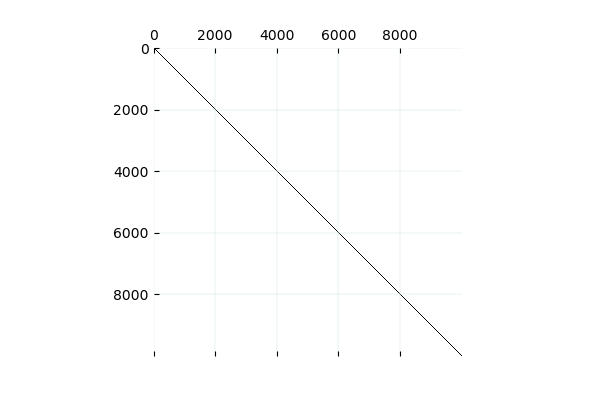

In [7]:
plt.figure()
plt.spy(A)

(0.0, 1.0, 0.0, 1.0)

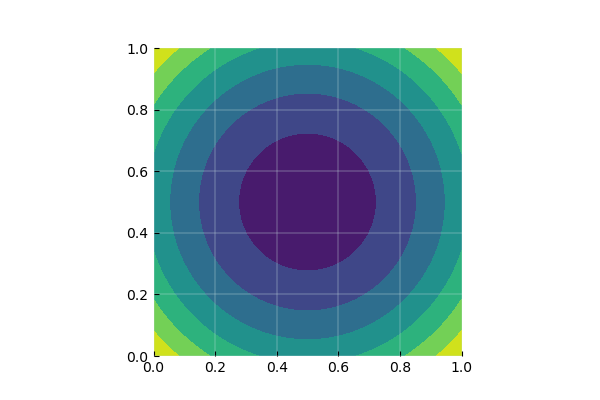

In [8]:
plt.figure()
plt.contourf(X, Y, b)
plt.axis("image")

## Imposición de condiciones de frontera

In [9]:
id_inf = list(range(0, Nx))
id_sup = list(range((Ny - 1)*Nx, (Ny - 1)*Nx + Nx))
id_izq = list(range(0, (Ny - 1)*Nx + 1, Nx))
id_der = list(range(Nx - 1, Ny*Nx + 1, Nx))

id_frontera = id_inf + id_sup + id_izq + id_der

In [10]:
b.shape = Nx * Ny, 
for id in id_frontera:
    A[id, :] = 0
    A[id, id] = 1
    b[id] = 0

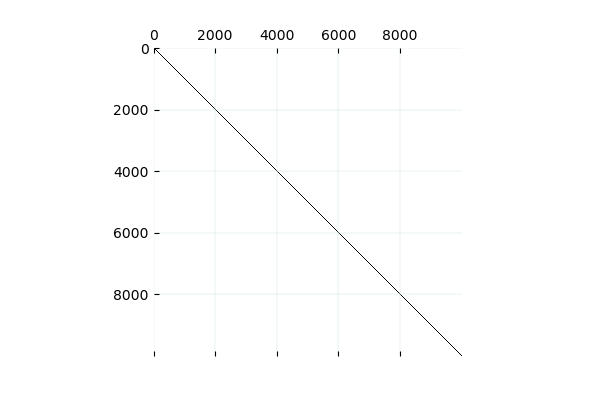

In [11]:
plt.figure()
plt.spy(A)

## Solución del sistema de ecuaciones

In [12]:
sol = solve(A, b.flatten())

In [13]:
sol_ex = X * (1 - X) * Y * (1 - Y)

(0.0, 1.0, 0.0, 1.0)

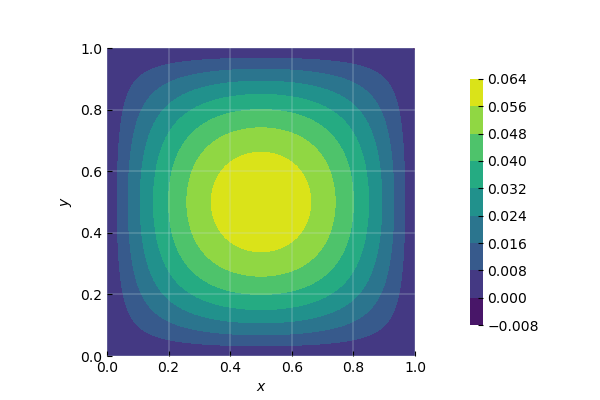

In [14]:
plt.figure()
plt.contourf(X, Y, np.reshape(sol, (Nx, Ny)))
plt.colorbar(shrink=0.8)
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.axis("image")

(0.0, 1.0, 0.0, 1.0)

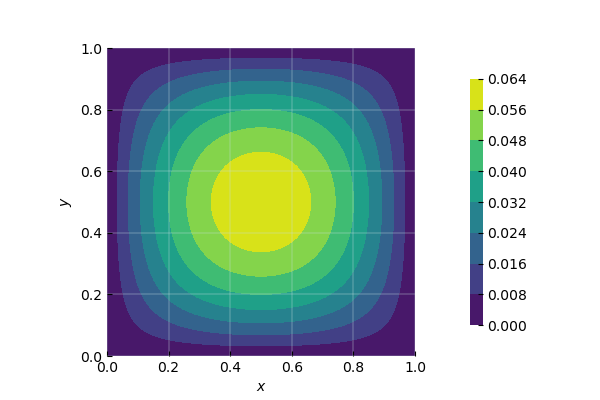

In [15]:
plt.figure()
plt.contourf(X, Y, sol_ex)
plt.colorbar(shrink=0.8)
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.axis("image")

(0.0, 1.0, 0.0, 1.0)

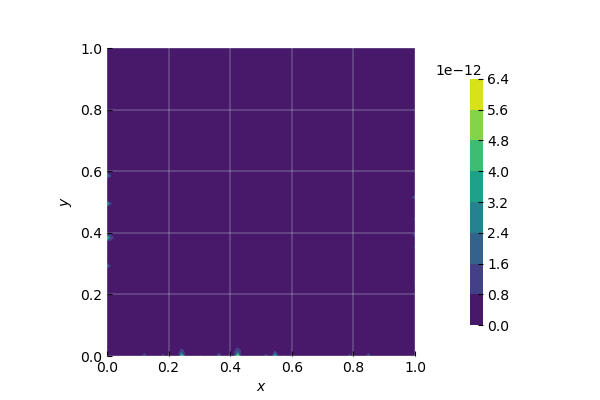

In [16]:
plt.figure()
plt.contourf(X, Y, np.abs(sol_ex - np.reshape(sol, (Nx, Ny))))
plt.colorbar(shrink=0.8)
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.axis("image")